In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better plots
plt.style.use("seaborn-v0_8")
df = pd.read_csv("spg.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
df["generated_power_kw"].describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4213 entries, 0 to 4212
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   temperature_2_m_above_gnd          4213 non-null   float64
 1   relative_humidity_2_m_above_gnd    4213 non-null   int64  
 2   mean_sea_level_pressure_MSL        4213 non-null   float64
 3   total_precipitation_sfc            4213 non-null   float64
 4   snowfall_amount_sfc                4213 non-null   float64
 5   total_cloud_cover_sfc              4213 non-null   float64
 6   high_cloud_cover_high_cld_lay      4213 non-null   int64  
 7   medium_cloud_cover_mid_cld_lay     4213 non-null   int64  
 8   low_cloud_cover_low_cld_lay        4213 non-null   int64  
 9   shortwave_radiation_backwards_sfc  4213 non-null   float64
 10  wind_speed_10_m_above_gnd          4213 non-null   float64
 11  wind_direction_10_m_above_gnd      4213 non-null   float

count    4213.000000
mean     1134.347313
std       937.957247
min         0.000595
25%       231.700450
50%       971.642650
75%      2020.966700
max      3056.794100
Name: generated_power_kw, dtype: float64

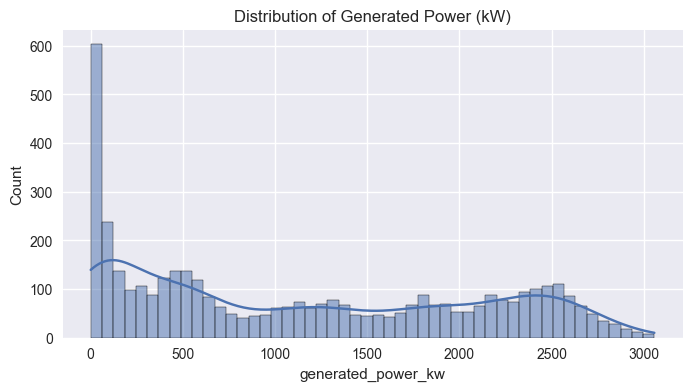

In [11]:
#visualize target distribution
plt.figure(figsize=(8,4))
sns.histplot(df["generated_power_kw"], bins=50, kde=True)
plt.title("Distribution of Generated Power (kW)")
plt.show()


In [12]:
#correlation with target
corr_with_target = df.corr(numeric_only=True)["generated_power_kw"].sort_values(ascending=False)

corr_with_target


generated_power_kw                   1.000000
shortwave_radiation_backwards_sfc    0.556148
temperature_2_m_above_gnd            0.217280
mean_sea_level_pressure_MSL          0.150551
snowfall_amount_sfc                 -0.049508
azimuth                             -0.061184
wind_direction_80_m_above_gnd       -0.069941
wind_direction_10_m_above_gnd       -0.073257
wind_direction_900_mb               -0.077435
wind_speed_10_m_above_gnd           -0.083043
wind_speed_900_mb                   -0.107615
total_precipitation_sfc             -0.118442
wind_gust_10_m_above_gnd            -0.122808
high_cloud_cover_high_cld_lay       -0.147723
wind_speed_80_m_above_gnd           -0.157899
medium_cloud_cover_mid_cld_lay      -0.227834
low_cloud_cover_low_cld_lay         -0.288066
total_cloud_cover_sfc               -0.334338
relative_humidity_2_m_above_gnd     -0.336783
angle_of_incidence                  -0.646537
zenith                              -0.649991
Name: generated_power_kw, dtype: f

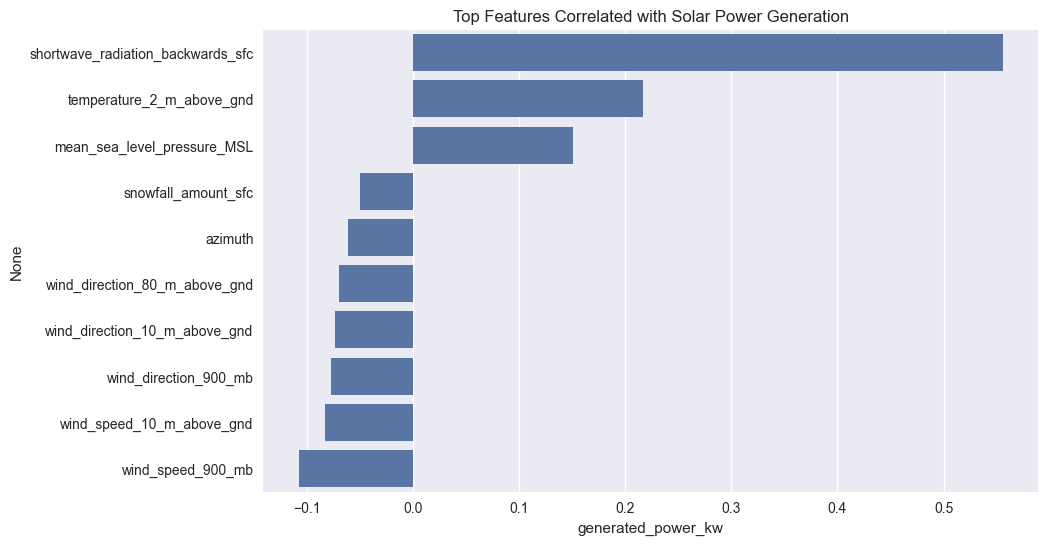

In [13]:
#visulaize top correlations
top_features = corr_with_target.index[1:11]  # skip target itself

plt.figure(figsize=(10,6))
sns.barplot(
    x=corr_with_target[top_features],
    y=top_features
)
plt.title("Top Features Correlated with Solar Power Generation")
plt.show()


In [14]:
X = df.drop(columns=["generated_power_kw"])
y = df["generated_power_kw"]


In [16]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 391.7926956840305
RMSE: 507.5323218220514
R2 Score: 0.7180084563489011


In [18]:
#random forest regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)


Random Forest MAE: 255.60428237061896
Random Forest RMSE: 407.7406518440088
Random Forest R2: 0.8179977737567238


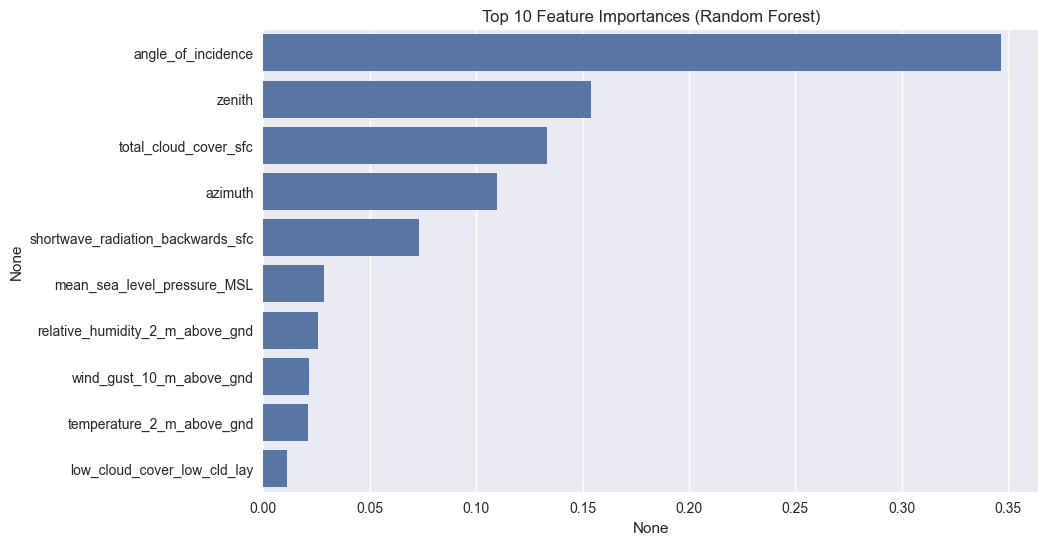

In [19]:
#feature importance
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=feature_importance.head(10),
    y=feature_importance.head(10).index
)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


In [20]:
#create power level classes 
# Define thresholds
low_threshold = df["generated_power_kw"].quantile(0.33)
high_threshold = df["generated_power_kw"].quantile(0.66)

def power_level(power):
    if power <= low_threshold:
        return "Low"
    elif power <= high_threshold:
        return "Medium"
    else:
        return "High"

df["power_level"] = df["generated_power_kw"].apply(power_level)

df["power_level"].value_counts()


power_level
High      1433
Medium    1390
Low       1390
Name: count, dtype: int64

In [23]:
#prepare data for classification
X_cls = df.drop(columns=["generated_power_kw", "power_level"])
y_cls = df["power_level"]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)
from sklearn.ensemble import RandomForestClassifier

rf_cls = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_cls.fit(X_train_c, y_train_c)

y_pred_c = rf_cls.predict(X_test_c)
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_c, y_pred_c))


              precision    recall  f1-score   support

        High       0.85      0.87      0.86       287
         Low       0.88      0.82      0.85       278
      Medium       0.72      0.76      0.74       278

    accuracy                           0.81       843
   macro avg       0.82      0.81      0.82       843
weighted avg       0.82      0.81      0.82       843



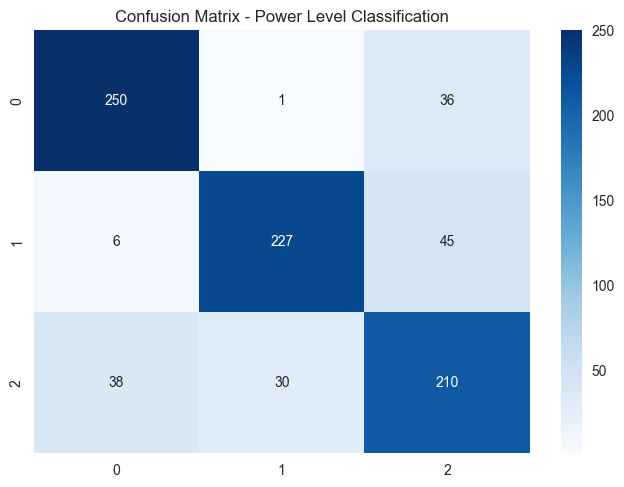

In [24]:
sns.heatmap(confusion_matrix(y_test_c, y_pred_c),
            annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Power Level Classification")
plt.show()


In [26]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf, "solar_power_rf_model.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), "model_features.pkl")


['model_features.pkl']

In [27]:
import os
print(os.getcwd())


C:\Users\Aditya Dwivedi\OneDrive\Desktop\SOLAR POWER PREDICTION


In [28]:
import joblib

# Make sure you are saving to the correct folder
joblib.dump(rf, r"C:\Users\Aditya Dwivedi\OneDrive\Desktop\SOLAR POWER PREDICTION\solar_power_rf_model.pkl")
joblib.dump(X.columns.tolist(), r"C:\Users\Aditya Dwivedi\OneDrive\Desktop\SOLAR POWER PREDICTION\model_features.pkl")


['C:\\Users\\Aditya Dwivedi\\OneDrive\\Desktop\\SOLAR POWER PREDICTION\\model_features.pkl']

NameError: name 'input_df' is not defined